<a href="https://colab.research.google.com/github/abrar2akib/Sample-Codes/blob/main/Monte%20Carlo%20Simulation/PPA_Monte_Carlo_with_Payment_Delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Monte Carlo for all scenarios...
  Simulations: 10,000 | Bootstraps: 1,000 | Years: 20

  → Baseline_50MW ... done. Det NPV = $43,789,006
  → LC_50MW ... done. Det NPV = $44,545,347
  → Escrow_50MW ... done. Det NPV = $44,622,840
  → IA_50MW ... done. Det NPV = $44,489,543
  → Baseline_NoBalloon ... done. Det NPV = $-6,728,591
  → LC_NoBalloon ... done. Det NPV = $34,366,509
  → Baseline_10MW ... done. Det NPV = $8,596,851
  → Baseline_100MW ... done. Det NPV = $88,195,263
  → Escrow_FrontLoaded ... done. Det NPV = $51,766,195
  → Escrow_BackLoaded ... done. Det NPV = $37,028,946
  → Partial_Baseline_50MW ... done. Det NPV = $-7,154,229
  → Partial_LC_50MW ... done. Det NPV = $-6,776,059
  → Partial_Escrow_50MW ... done. Det NPV = $-6,737,313
  → Baseline_FX_Index ... done. Det NPV = $41,241,844
  → Baseline_Infl_Index ... done. Det NPV = $49,625,677
  → Baseline_Both_Index ... done. Det NPV = $46,925,686
  → BestCase ... done. Det NPV = $110,994,507
  → WorstCase ... done. Det

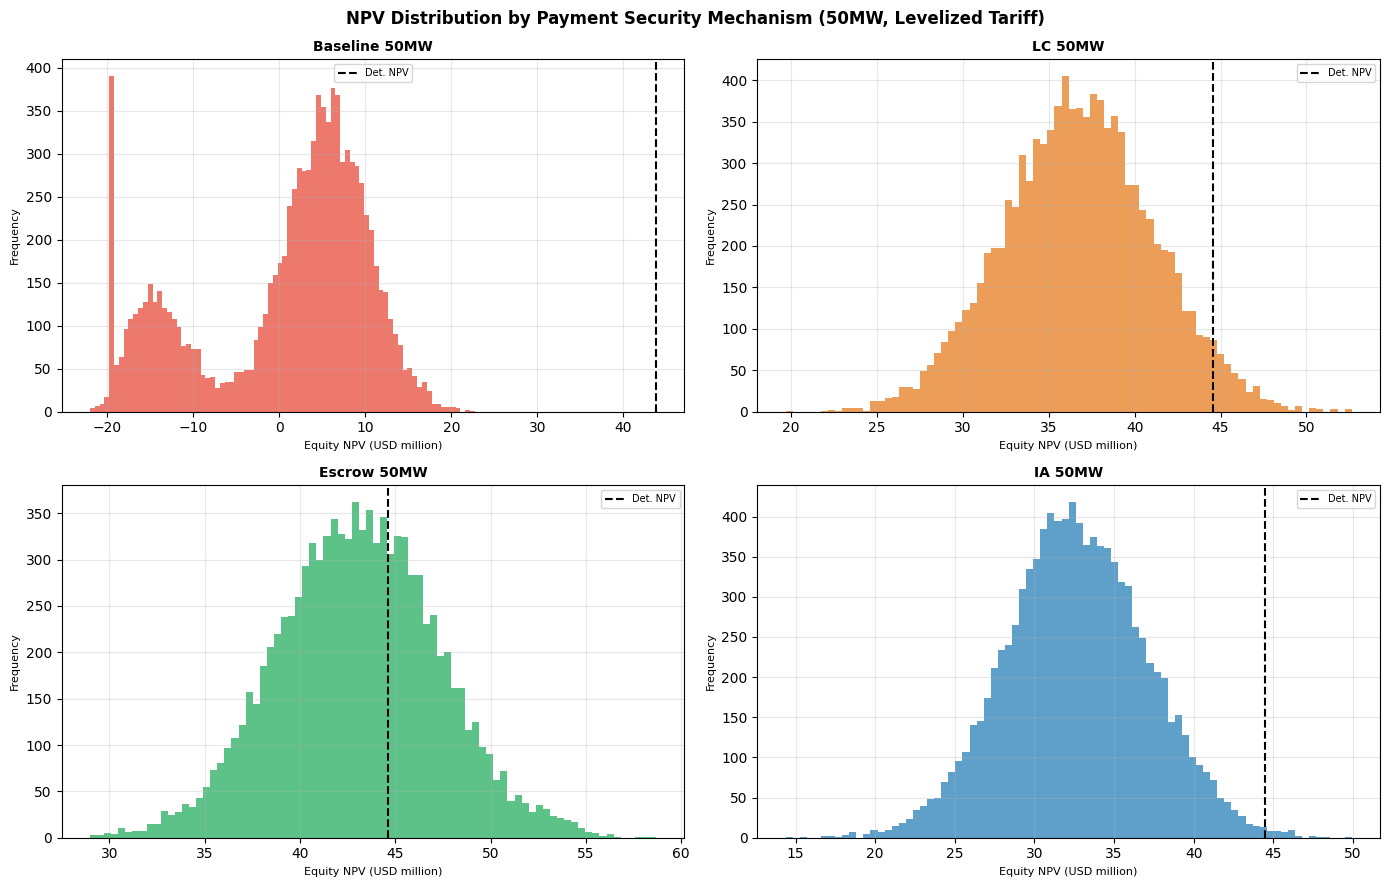

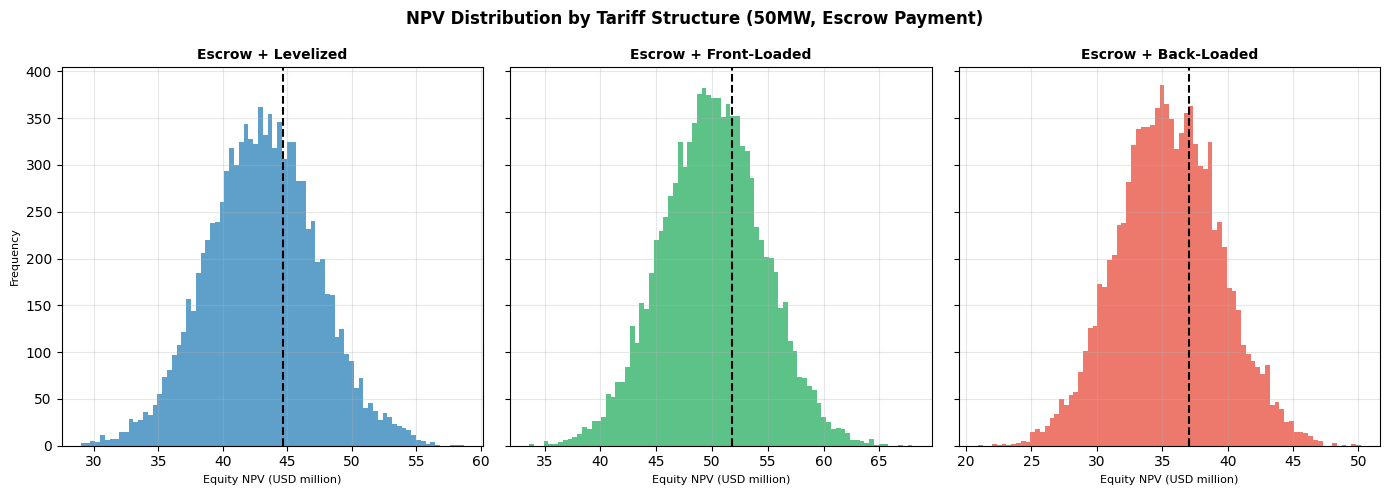

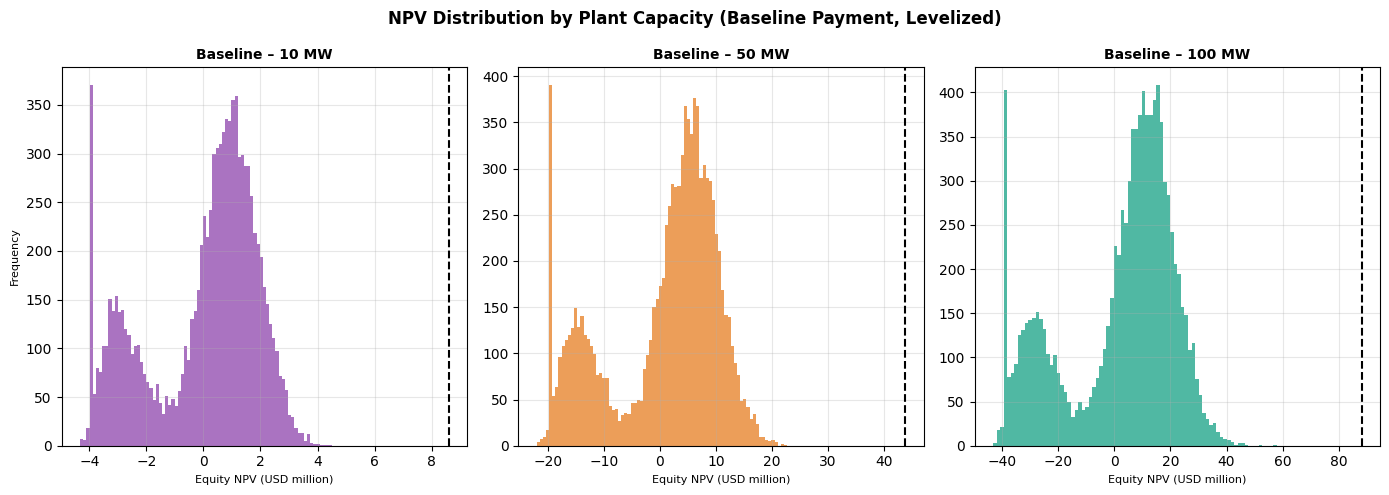

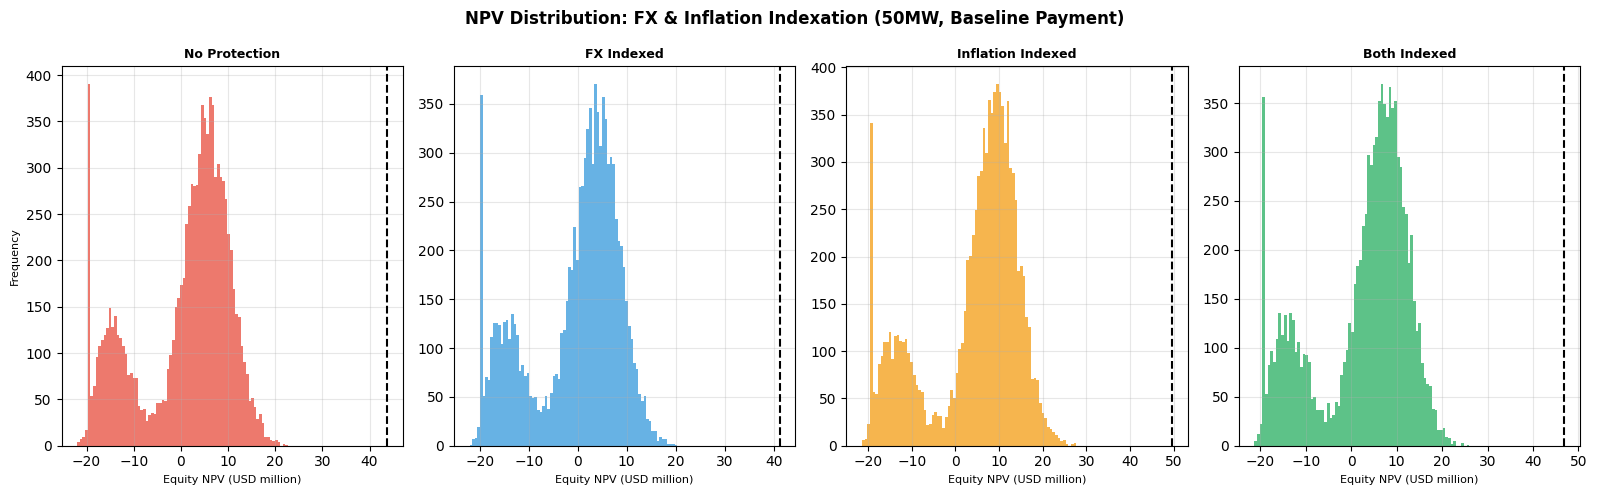

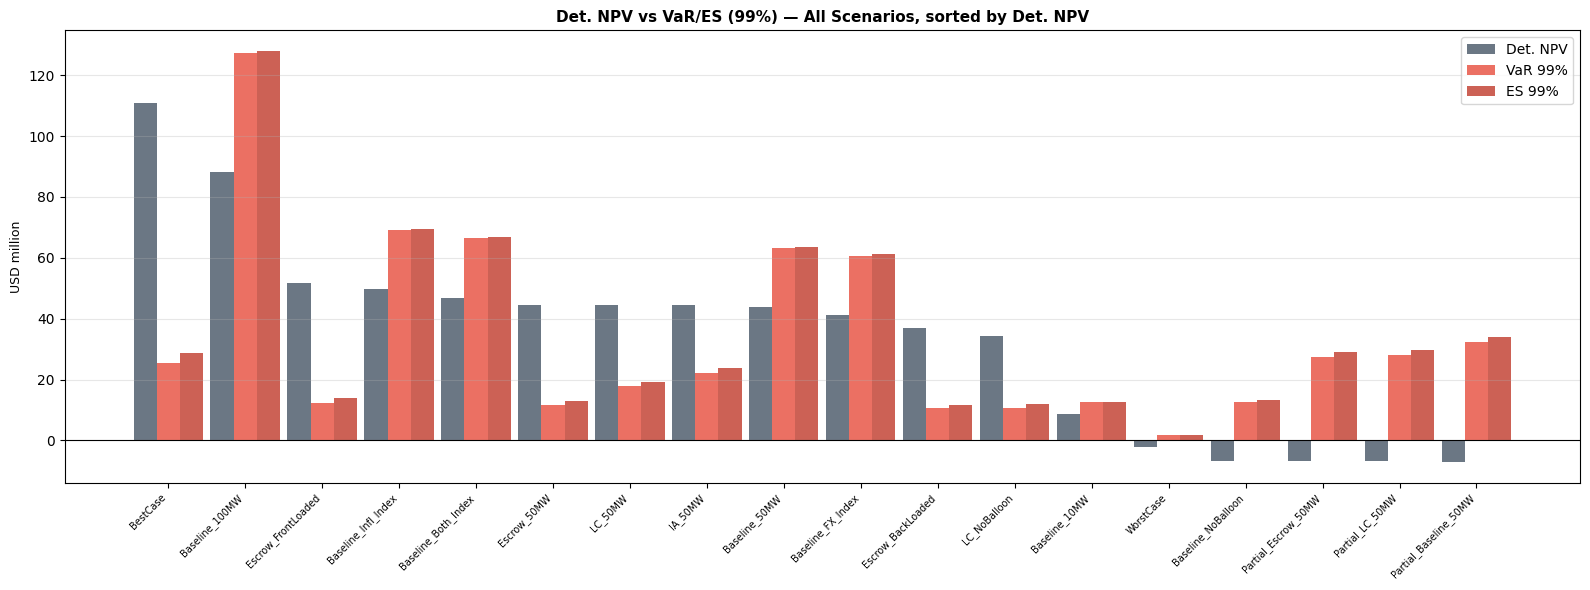

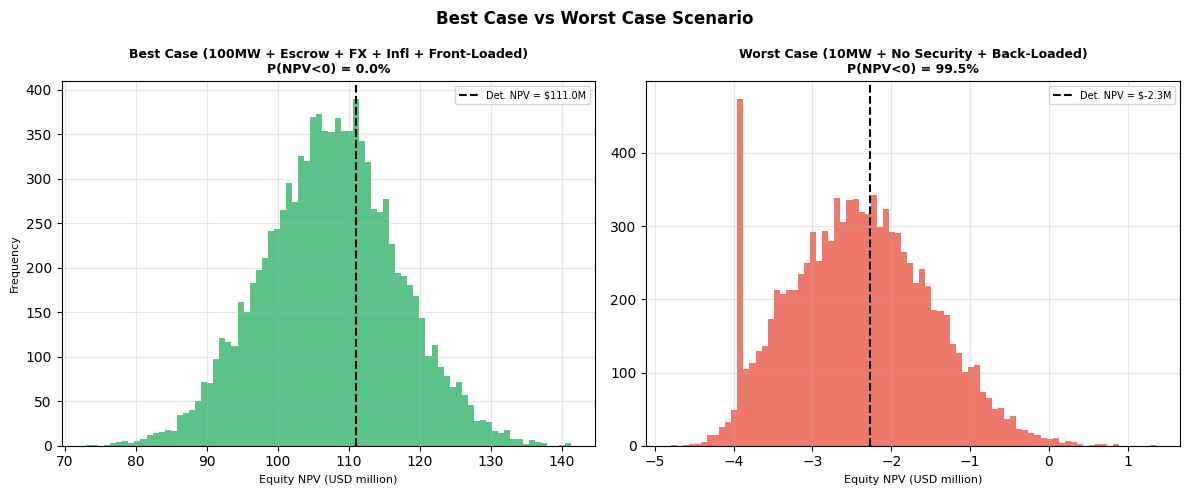

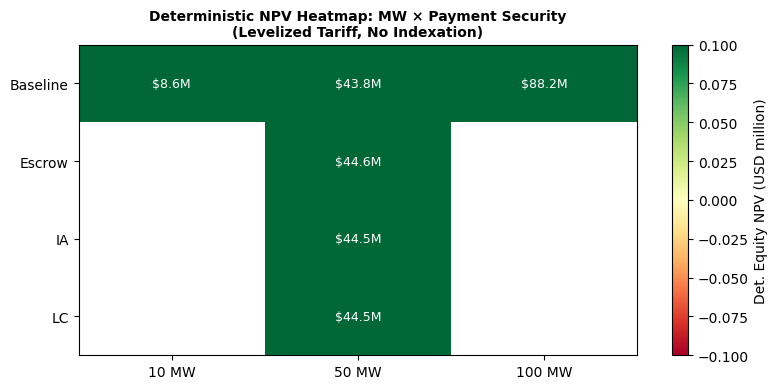



Files saved:
  ppa_var_es_results_revised.csv      — full results table (all scenarios × both alphas)
  ppa_var_es_npvs_all_scenarios.csv   — raw NPV arrays for all scenarios
  chart1_payment_security.pdf
  chart2_tariff_structure.pdf
  chart3_plant_size.pdf
  chart4_indexation.pdf
  chart5_var_es_comparison.pdf
  chart6_best_vs_worst.pdf
  chart7_npv_heatmap.pdf


In [ ]:
# -*- coding: utf-8 -*-
"""
PPA Monte Carlo – Revised
==========================
Sources: KII survey (PPA_Parameter_Questions_curated.xlsx) + original model logic

KEY CHANGES FROM ORIGINAL:
  1. All input parameters consolidated at the top (change here, runs everywhere)
  2. Monthly→yearly conversion: payment stress triggered by 6-month delay window,
     not consecutive annual non-payments
  3. O&M profile: low early years (1-5), rising thereafter
  4. Capacity degradation: −2% Y1, −0.45%/yr thereafter (KII-calibrated)
  5. Multiple scenarios: plant size, tariff structure (front/level/back),
     payment security (Baseline/LC/Escrow/IA), full vs partial payment,
     FX and inflation indexation options
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from math import isfinite

np.random.seed(42)

# ============================================================
#  SECTION 1: ALL INPUT PARAMETERS  (change here to experiment)
# ============================================================

# --- Project fundamentals ---
YEARS           = 20          # Plant lifetime (KII: 20 years)
SIMULATIONS     = 10_000      # Monte Carlo draws
BOOTSTRAPS      = 1_000       # Bootstrap iterations for CI
HOURS_PER_YEAR  = 8_760       # KII: 8760 hours per year (gross; CF handles actual output)

# --- Capacity options (MW) ---
# KII: "100MW–10MW" range. Modelled as discrete scenarios.
PLANT_CAPACITIES_MW = {
    'Small_10MW':  10,
    'Medium_50MW': 50,
    'Large_100MW': 100,
}
DEFAULT_CAPACITY_MW = 50      # used in single-scenario runs

# --- Capacity factor (generation) ---
# KII: average CF = 0.23; Y1 degradation −2%, subsequent −0.45%/yr
BASELINE_CF                 = 0.23   # Year-1 capacity factor
CF_DEGRADATION_Y1           = 0.02   # Drop after first year
CF_DEGRADATION_ANNUAL       = 0.0045 # Subsequent annual degradation
CAPACITY_CF_SD              = 0.03   # Year-to-year stochastic noise (std dev)
CF_CLIP_LOWER               = 0.40 / 100.0  # Min CF (absolute floor; KII: 40MW/100MW = 0.40)
CF_CLIP_UPPER               = 1.35          # Max CF ratio (KII: 130–135MW / 100MW)
# NOTE: clip is applied to the stochastic shock; degradation is deterministic on mean

# --- Tariff ---
# KII reported tariffs: 6.5–8.13 cent/kWh → use 7.66 USD/MWh as central estimate
TARIFF_USD_PER_MWH   = 152.0   # USD/MWh (7.66 cent/kWh converted) #76.6
TARIFF_ESCALATION    = 0.00   # KII: 0 (no escalation in baseline)
TARIFF_ESCALATION_SD = 0.00   # KII: 0 (fixed tariff)

# Tariff structure options for scenario analysis
# "front_loaded"  → higher escalation in early years, declines later
# "levelized"     → flat (no escalation)
# "back_loaded"   → lower early, higher later
# These are modelled as annual escalation schedules (list of length YEARS)
def tariff_schedule(mode, years=YEARS, base_tariff=TARIFF_USD_PER_MWH):
    """
    Returns list of per-year tariff values.
    front_loaded:  starts at 1.10× base, declines 0.5%/yr
    levelized:     flat base throughout
    back_loaded:   starts at 0.90× base, grows 0.5%/yr
    """
    tariffs = []
    t = base_tariff
    for yr in range(1, years + 1):
        if mode == 'front_loaded':
            t = base_tariff * (1.10) * ((1 - 0.005) ** (yr - 1))
        elif mode == 'back_loaded':
            t = base_tariff * (0.90) * ((1 + 0.005) ** (yr - 1))
        else:  # levelized
            t = base_tariff
        tariffs.append(t)
    return tariffs

# --- Payment behaviour ---
# KII mechanics (confirmed): BPDB invoices are monthly. Each month BPDB either pays
# the OLDEST outstanding invoice in full (prob = PAYMENT_PROB_MONTHLY) or pays nothing
# that month (binary, FIFO queue). Example: in March they received November's payment.
# Payments always arrive eventually within the PPA term; there is no permanent write-off
# in the baseline (arrears are cleared, possibly at PPA termination if not before).
#
# KEY VARIABLES TO ADJUST:
PAYMENT_PROB_MONTHLY_BASELINE = 0.50   # KII: 50% chance BPDB clears oldest invoice each month

# Payment security mechanisms → monthly clearance probability overrides
PAYMENT_PROB_MONTHLY = {
    'Baseline':  0.50,   # No security; KII base — ~4–6 month average delay
    'LC':        0.90,   # Letter of Credit: bank pays IPP on invoice date, reclaims from BPDB
    'Escrow':    0.98,   # Escrow account: dedicated fund, near-certain monthly clearing
    'IA':        0.85,   # Implementation Agreement: sovereign guarantee, somewhat slower
}

# Payment delay model — controls whether arrears are recovered and how
# BALLOON_PAYMENT_AT_END: True = all unpaid invoices at PPA term are settled as lump sum
#   (realistic for BD: government typically clears arrears at contract close)
# BALLOON_PAYMENT_AT_END: False = invoices uncleared within horizon are lost permanently
BALLOON_PAYMENT_AT_END  = True    # Change to False to model permanent revenue loss

# Financial stress trigger: consecutive months without ANY payment clearing
STRESS_TRIGGER_MONTHS   = 6       # KII: 6 months → plant enters financial stress
DSCR_GRACE_PERIOD_YEARS = 5       # KII: "very critical in first 3–5 years"

# Partial payment parameters (no partial payment in BPDB baseline; policy scenario only)
# When partial_payment = True in a scenario, each month BPDB may pay a fraction
# of the oldest invoice instead of full-or-nothing
PARTIAL_PAYMENT_ALLOWED      = False  # Default: False (KII confirmed no partial payment)
PARTIAL_PAYMENT_FRAC_MEAN    = 0.50   # If partial: expected fraction paid per episode
PARTIAL_PAYMENT_FRAC_SD      = 0.15   # Variability around that fraction

# Beta distribution parameters for partial payment fraction draw
# Beta(a,b) shapes the distribution of what fraction gets paid when partial
BETA_A = 5    # With mean=0.5, Beta(5,5) gives symmetric dist around 50%
BETA_B = 5    # Increase both to tighten; decrease to widen

# --- O&M costs ---
# KII: 100MW plant = 1.5 crore BDT/month ≈ USD 1.23M/yr (at 1 USD = 122 BDT)
#   → 12,300 USD/MW/year for 100MW plant
# KII: "smaller plants incur proportionately more cost" → scale factor applied
# KII: "first 5 years cost is very low; after that cost increases"
OM_USD_PER_MW_BASE  = 12_300.0  # Base for 100MW (calibrated from KII)
OM_SCALE_EXPONENT   = -0.10     # Negative → smaller plants cost more per MW (slight diseconomy)
# O&M profile multipliers by year-bucket (relative to base)
OM_PROFILE = {
    'early':  0.50,   # Years 1–5: very low (KII)
    'mid':    1.00,   # Years 6–12: normal
    'late':   1.40,   # Years 13–20: elevated maintenance
}
OM_COST_SD = 0.15   # Log-normal sigma for year-to-year variability

# --- CAPEX and financing ---
# KII: 121 million USD for 100MW → 1,210,000 USD/MW
CAPEX_USD_PER_MW   = 1_300_000.0   # KII: 121M/100MW
DEBT_EQUITY_RATIO  = 0.70           # KII: 70:30
DEBT_TENOR_YEARS   = 20             # KII: 20 years
DEBT_INTEREST_RATE = 0.065          # KII: 6–7% → use 6.5%
WACC               = 0.105          # KII: 10–11% → use 10.5%

# --- FX and Inflation Indexation (scenario switches) ---
# If FX_INDEXATION = True: tariff is partially protected from BDT/USD movements
# If INFLATION_INDEXATION = True: O&M costs grow with inflation; tariff also adjusted
FX_INDEXATION        = False   # Baseline: no FX protection
INFLATION_INDEXATION = False   # Baseline: no inflation linkage
FX_ANNUAL_DEPRECIATION = 0.05  # BDT depreciates ~5%/yr against USD (approximate)
INFLATION_RATE         = 0.06  # Bangladesh CPI ~6%/yr
FX_PROTECTION_FRACTION = 0.50  # If FX indexation on: 50% of tariff is USD-linked

# ============================================================
#  SECTION 2: DERIVED QUANTITIES  (do not need to change)
# ============================================================

def annuity(r, n):
    if abs(r) < 1e-12:
        return 1.0 / n
    return r / (1 - (1 + r) ** (-n))

def om_for_year(t, capacity_mw):
    """O&M cost USD for year t (1-indexed), accounting for plant size and age profile."""
    # Scale: larger plants cheaper per MW
    scale = (capacity_mw / 100.0) ** OM_SCALE_EXPONENT
    base = OM_USD_PER_MW_BASE * scale * capacity_mw
    if t <= 5:
        return base * OM_PROFILE['early']
    elif t <= 12:
        return base * OM_PROFILE['mid']
    else:
        return base * OM_PROFILE['late']

def degraded_cf_mean(t):
    """Deterministic mean CF in year t (1-indexed), applying KII degradation profile."""
    if t == 1:
        return BASELINE_CF
    cf = BASELINE_CF - CF_DEGRADATION_Y1
    cf -= CF_DEGRADATION_ANNUAL * (t - 2)
    return max(cf, 0.05)

def simulate_payment_queue(payment_prob_monthly, years=YEARS,
                           partial_pay=False, balloon=BALLOON_PAYMENT_AT_END):
    """
    FIFO payment queue model matching KII-described mechanics:
      - Plant issues one invoice per month (12 × years invoices total)
      - Each month: with prob=payment_prob_monthly, BPDB clears the OLDEST unpaid invoice
        in full (binary: full payment or nothing for that month's attempt)
      - If partial_pay=True: when BPDB pays, it pays a Beta-distributed fraction of the
        oldest invoice rather than the full amount (policy scenario, not current practice)
      - If balloon=True: all remaining unpaid invoices at end of horizon are paid as a
        lump sum in the final period (realistic for BD PPA termination settlement)
      - Stress detection: track consecutive months with zero clearance

    Returns (per-year arrays, length=years):
      cash_received_by_year  : USD amount received in each calendar year (as fraction of
                               that year's invoiced revenue; caller multiplies by revenue)
      stressed_year          : bool array — True if ≥ STRESS_TRIGGER_MONTHS consecutive
                               months without clearance occurred in or before that year
      avg_delay_months       : average payment delay (months) across all paid invoices
    """
    total_months = years * 12
    # invoice_value is a placeholder unit (1.0 per month); caller scales by actual monthly revenue
    queue        = []     # list of (invoice_month_idx, fraction_remaining)
    cash_by_month= np.zeros(total_months)
    consec_fail  = 0
    stressed_flag= False
    stressed_by_month = np.zeros(total_months, dtype=bool)
    paid_delays  = []

    for m in range(total_months):
        # New invoice arrives (unit value = 1.0)
        queue.append([m, 1.0])   # [invoice_month, fraction_outstanding]

        cleared_this_month = False
        if queue and np.random.rand() < payment_prob_monthly:
            if partial_pay:
                # Pay a Beta-distributed fraction of oldest invoice
                frac = np.random.beta(BETA_A, BETA_B)
                frac = np.clip(frac, 0.05, 1.0)
                inv  = queue[0]
                cash_by_month[m] += frac * inv[1]
                inv[1] -= frac * inv[1]
                if inv[1] < 0.01:   # fully cleared
                    paid_delays.append(m - inv[0])
                    queue.pop(0)
                cleared_this_month = True
            else:
                # Full clearance of oldest invoice
                inv = queue.pop(0)
                cash_by_month[m] += inv[1]   # inv[1] == 1.0 always in full-pay mode
                paid_delays.append(m - inv[0])
                cleared_this_month = True

        # Stress tracking
        if cleared_this_month:
            consec_fail = 0
        else:
            consec_fail += 1
        if consec_fail >= STRESS_TRIGGER_MONTHS:
            stressed_flag = True
        stressed_by_month[m] = stressed_flag

    # Balloon: remaining queue paid in last month of horizon
    if balloon and queue:
        for inv in queue:
            cash_by_month[-1] += inv[1]
            paid_delays.append((total_months - 1) - inv[0])
        queue = []

    # Aggregate to years
    cash_by_year   = cash_by_month.reshape(years, 12).sum(axis=1)   # sum of unit fractions per year
    stressed_year  = stressed_by_month.reshape(years, 12).any(axis=1)
    avg_delay      = float(np.mean(paid_delays)) if paid_delays else float(total_months)

    # cash_by_year[t] = number of invoice-units collected in year t (out of 12 possible)
    # Divide by 12 to get fraction of annual revenue actually received in that year
    revenue_frac_by_year = cash_by_year / 12.0

    return revenue_frac_by_year, stressed_year, avg_delay

# ============================================================
#  SECTION 3: CORE SIMULATION ENGINE
# ============================================================

def simulate_npvs(scenario_params, sims=SIMULATIONS):
    """
    Run Monte Carlo for a single scenario. Returns array of simulated equity NPVs.

    scenario_params keys:
      capacity_mw            : plant size (MW)
      payment_prob_monthly   : monthly clearance probability (FIFO queue)
      partial_payment        : bool – allow partial invoice clearance (policy scenario)
      balloon_payment        : bool – unpaid arrears settled at PPA end
      tariff_mode            : 'levelized' | 'front_loaded' | 'back_loaded'
      fx_indexation          : bool
      inflation_indexation   : bool
    """
    capacity_mw   = scenario_params.get('capacity_mw', DEFAULT_CAPACITY_MW)
    pay_prob      = scenario_params.get('payment_prob_monthly', PAYMENT_PROB_MONTHLY['Baseline'])
    partial_pay   = scenario_params.get('partial_payment', PARTIAL_PAYMENT_ALLOWED)
    balloon       = scenario_params.get('balloon_payment', BALLOON_PAYMENT_AT_END)
    tariff_mode   = scenario_params.get('tariff_mode', 'levelized')
    fx_index      = scenario_params.get('fx_indexation', FX_INDEXATION)
    infl_index    = scenario_params.get('inflation_indexation', INFLATION_INDEXATION)

    capex     = CAPEX_USD_PER_MW * capacity_mw
    debt_amt  = capex * DEBT_EQUITY_RATIO
    equity    = capex - debt_amt
    ann_debt  = debt_amt * annuity(DEBT_INTEREST_RATE, DEBT_TENOR_YEARS)

    base_tariff_schedule = tariff_schedule(tariff_mode)   # list of length YEARS

    npv_list = np.zeros(sims)

    for s in range(sims):
        # --- Stochastic shocks ---
        cf_noise    = np.random.normal(0, CAPACITY_CF_SD, size=YEARS)
        om_shocks   = np.random.lognormal(mean=0, sigma=OM_COST_SD, size=YEARS)
        fx_shocks   = np.random.normal(FX_ANNUAL_DEPRECIATION, 0.02, size=YEARS) if fx_index  else np.zeros(YEARS)
        infl_shocks = np.random.normal(INFLATION_RATE, 0.01,          size=YEARS) if infl_index else np.zeros(YEARS)

        # --- Payment queue simulation (FIFO, monthly) ---
        # Returns revenue_frac_by_year: fraction of each year's invoiced revenue
        # actually received in that calendar year (accounts for delays + balloon)
        rev_frac, stressed_years, _ = simulate_payment_queue(
            pay_prob, years=YEARS, partial_pay=partial_pay, balloon=balloon
        )

        cashflows = [-equity]
        default_triggered = False
        default_year_idx  = YEARS

        for t_idx in range(YEARS):
            t = t_idx + 1

            # Capacity factor
            cf_t = np.clip(degraded_cf_mean(t) + cf_noise[t_idx], CF_CLIP_LOWER, CF_CLIP_UPPER)

            # Tariff
            tariff_t = base_tariff_schedule[t_idx]
            if fx_index:
                tariff_t = (tariff_t * FX_PROTECTION_FRACTION
                            + tariff_t * (1 - FX_PROTECTION_FRACTION) * (1 - fx_shocks[t_idx]))
            if infl_index:
                tariff_t *= (1 + infl_shocks[t_idx])

            # Revenue: full invoiced amount × fraction actually received this year
            gen_mwh  = capacity_mw * HOURS_PER_YEAR * cf_t
            revenue  = tariff_t * gen_mwh          # what was invoiced / earned this year
            rev_coll = revenue * rev_frac[t_idx]   # what was actually received (may include
                                                   # prior-year arrears; may exclude some of
                                                   # this year's if delayed into future year)

            # O&M
            om_base = om_for_year(t, capacity_mw)
            if infl_index:
                om_base *= (1 + infl_shocks[t_idx])
            om_t = om_base * om_shocks[t_idx]

            ebitda       = rev_coll - om_t
            debt_service = ann_debt if t <= DEBT_TENOR_YEARS else 0.0

            # Financial stress / default trigger (grace period)
            if t <= DSCR_GRACE_PERIOD_YEARS:
                if ebitda < debt_service and stressed_years[t_idx]:
                    if not default_triggered:
                        default_triggered = True
                        default_year_idx  = t_idx

            eq_cf = ebitda - debt_service
            if default_triggered and t_idx >= default_year_idx:
                eq_cf = 0.0

            cashflows.append(eq_cf)

        discount    = [1.0 / ((1 + WACC) ** t) for t in range(YEARS + 1)]
        npv_list[s] = sum(cf * d for cf, d in zip(cashflows, discount))

    return npv_list

# ============================================================
#  SECTION 4: DETERMINISTIC REFERENCE NPV
# ============================================================

def deterministic_npv(scenario_params):
    """
    Deterministic (expected-value) equity NPV.

    Payment delay is modelled as a time-value-of-money cost: with pay_prob p per month,
    the expected number of months until the oldest invoice is paid follows a Geometric(p)
    distribution with mean 1/p months. Revenue is received in full eventually (balloon=True)
    but arrives late, so each year's cash flow is discounted by the expected delay.
    Expected delay in months = (1/pay_prob - 1), i.e. for p=0.5 → 1 month extra wait.
    The present-value discount factor for a payment delayed d months is (1+WACC)^(-d/12).
    This gives a realistic deterministic reference: all invoices paid, but with time cost.
    """
    capacity_mw  = scenario_params.get('capacity_mw', DEFAULT_CAPACITY_MW)
    pay_prob     = scenario_params.get('payment_prob_monthly', PAYMENT_PROB_MONTHLY['Baseline'])
    partial_pay  = scenario_params.get('partial_payment', PARTIAL_PAYMENT_ALLOWED)
    balloon      = scenario_params.get('balloon_payment', BALLOON_PAYMENT_AT_END)
    tariff_mode  = scenario_params.get('tariff_mode', 'levelized')
    fx_index     = scenario_params.get('fx_indexation', FX_INDEXATION)
    infl_index   = scenario_params.get('inflation_indexation', INFLATION_INDEXATION)

    capex     = CAPEX_USD_PER_MW * capacity_mw
    debt_amt  = capex * DEBT_EQUITY_RATIO
    equity    = capex - debt_amt
    ann_debt  = debt_amt * annuity(DEBT_INTEREST_RATE, DEBT_TENOR_YEARS)

    # Expected delay: Geometric(p) → mean = 1/p months; extra wait beyond current month = 1/p − 1
    # If balloon=False (no recovery), expected fraction received = pay_prob (geometric series)
    if balloon:
        # All revenue eventually received; cost is purely time-value of delay
        expected_delay_months = max(0.0, (1.0 / pay_prob) - 1.0) if pay_prob > 0 else 24.0
        delay_pv_factor = (1 + WACC) ** (-expected_delay_months / 12.0)
        expected_rev_fraction = 1.0 * delay_pv_factor
    else:
        # No balloon: invoices not cleared within horizon are permanently lost
        # Expected fraction received within N months ≈ 1 − (1−p)^N; for large N ≈ 1 but
        # use pay_prob as the per-period "throughput" fraction for simplicity
        expected_rev_fraction = pay_prob

    # Partial payment adjustment to expected fraction
    if partial_pay:
        # With partial payment, each clearance event pays Beta(a,b) fraction
        # Expected fraction per event = BETA_A / (BETA_A + BETA_B)
        partial_frac = BETA_A / (BETA_A + BETA_B)
        expected_rev_fraction *= partial_frac

    base_sched = tariff_schedule(tariff_mode)
    cashflows  = [-equity]

    for t_idx in range(YEARS):
        t = t_idx + 1
        cf_t     = degraded_cf_mean(t)
        tariff_t = base_sched[t_idx]
        if fx_index:
            tariff_t = (tariff_t * FX_PROTECTION_FRACTION
                        + tariff_t * (1 - FX_PROTECTION_FRACTION) * (1 - FX_ANNUAL_DEPRECIATION))
        if infl_index:
            tariff_t *= (1 + INFLATION_RATE)

        gen_mwh  = capacity_mw * HOURS_PER_YEAR * cf_t
        revenue  = tariff_t * gen_mwh
        rev_coll = revenue * expected_rev_fraction   # full revenue × delay-discounted fraction

        om_base  = om_for_year(t, capacity_mw)
        if infl_index:
            om_base *= (1 + INFLATION_RATE)

        ebitda       = rev_coll - om_base
        debt_service = ann_debt if t <= DEBT_TENOR_YEARS else 0.0
        cashflows.append(ebitda - debt_service)

    discount = [1.0 / ((1 + WACC) ** t) for t in range(YEARS + 1)]
    return sum(cf * d for cf, d in zip(cashflows, discount))

# ============================================================
#  SECTION 5: RISK METRICS
# ============================================================

def var_es_and_ci(losses, alpha_list=(0.95, 0.99), boot=BOOTSTRAPS):
    losses = np.array(losses)
    N      = len(losses)
    results = {}
    for alpha in alpha_list:
        k   = int(np.ceil(alpha * N)) - 1
        srt = np.sort(losses)
        VaR = srt[k]
        ES  = srt[k:].mean() if k < N - 1 else srt[-1]

        boot_stats = np.zeros((boot, 2))
        for b in range(boot):
            s   = np.sort(np.random.choice(losses, size=N, replace=True))
            kk  = int(np.ceil(alpha * N)) - 1
            boot_stats[b, 0] = s[kk]
            boot_stats[b, 1] = s[kk:].mean() if kk < N - 1 else s[-1]

        results[alpha] = {
            'VaR':    VaR,
            'VaR_CI': (np.percentile(boot_stats[:, 0], 2.5), np.percentile(boot_stats[:, 0], 97.5)),
            'ES':     ES,
            'ES_CI':  (np.percentile(boot_stats[:, 1], 2.5), np.percentile(boot_stats[:, 1], 97.5)),
        }
    results['summary'] = {
        'mean_loss':       losses.mean(),
        'median_loss':     np.median(losses),
        'pct_loss_pos':    np.mean(losses > 0),
        'mean_npv':        -losses.mean(),          # approx; det_npv offsets losses
        'prob_negative_npv': np.mean(losses > 0),
    }
    return results

# ============================================================
#  SECTION 6: SCENARIO DEFINITIONS
# ============================================================

# Each scenario is a dict of overrides; missing keys use module-level defaults.
# balloon_payment key: True = arrears settled at PPA end (default); False = permanent loss
SCENARIOS = {
    # ── Payment security mechanisms (50MW, levelized, balloon on) ──
    'Baseline_50MW':        {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': True},
    'LC_50MW':              {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['LC'],        'tariff_mode': 'levelized',     'balloon_payment': True},
    'Escrow_50MW':          {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Escrow'],    'tariff_mode': 'levelized',     'balloon_payment': True},
    'IA_50MW':              {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['IA'],        'tariff_mode': 'levelized',     'balloon_payment': True},

    # ── No balloon (permanent loss): stress test — what if arrears are never recovered ──
    'Baseline_NoBalloon':   {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': False},
    'LC_NoBalloon':         {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['LC'],        'tariff_mode': 'levelized',     'balloon_payment': False},

    # ── Plant size comparison (Baseline payment, levelized, balloon on) ──
    'Baseline_10MW':        {'capacity_mw': 10, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': True},
    'Baseline_100MW':       {'capacity_mw':100, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': True},

    # ── Tariff structure (50MW, Escrow payment, balloon on) ──
    'Escrow_FrontLoaded':   {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Escrow'],    'tariff_mode': 'front_loaded',  'balloon_payment': True},
    'Escrow_BackLoaded':    {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Escrow'],    'tariff_mode': 'back_loaded',   'balloon_payment': True},

    # ── Partial payment policy scenarios (not current practice; what-if) ──
    # Partial payment = BPDB pays a fraction of the oldest invoice instead of full-or-nothing
    # This is a POLICY PROPOSAL scenario to explore whether partial payment improves cash flow
    'Partial_Baseline_50MW': {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'], 'tariff_mode': 'levelized',    'balloon_payment': True,  'partial_payment': True},
    'Partial_LC_50MW':       {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['LC'],       'tariff_mode': 'levelized',    'balloon_payment': True,  'partial_payment': True},
    'Partial_Escrow_50MW':   {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Escrow'],   'tariff_mode': 'levelized',    'balloon_payment': True,  'partial_payment': True},

    # ── FX & Inflation indexation (50MW, Baseline payment, balloon on) ──
    'Baseline_FX_Index':    {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': True,  'fx_indexation': True},
    'Baseline_Infl_Index':  {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': True,  'inflation_indexation': True},
    'Baseline_Both_Index':  {'capacity_mw': 50, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'levelized',     'balloon_payment': True,  'fx_indexation': True, 'inflation_indexation': True},

    # ── Best case: 100MW + Escrow + FX + Infl index + Front-loaded ──
    'BestCase':             {'capacity_mw':100, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Escrow'],    'tariff_mode': 'front_loaded',  'balloon_payment': True,  'fx_indexation': True, 'inflation_indexation': True},

    # ── Worst case: 10MW + No security + Back-loaded + No balloon ──
    'WorstCase':            {'capacity_mw': 10, 'payment_prob_monthly': PAYMENT_PROB_MONTHLY['Baseline'],  'tariff_mode': 'back_loaded',   'balloon_payment': False},
}

# ============================================================
#  SECTION 7: RUN ALL SCENARIOS
# ============================================================

print("Running Monte Carlo for all scenarios...")
print(f"  Simulations: {SIMULATIONS:,} | Bootstraps: {BOOTSTRAPS:,} | Years: {YEARS}\n")

all_results = {}
all_npvs    = {}

for name, params in SCENARIOS.items():
    print(f"  → {name} ...", end='', flush=True)
    npvs      = simulate_npvs(params, sims=SIMULATIONS)
    det_npv   = deterministic_npv(params)
    losses    = det_npv - npvs
    risk_res  = var_es_and_ci(losses, alpha_list=(0.95, 0.99), boot=BOOTSTRAPS)
    all_results[name] = {'det_npv': det_npv, 'risk': risk_res}
    all_npvs[name]    = npvs
    print(f" done. Det NPV = ${det_npv:,.0f}")

# ============================================================
#  SECTION 8: DETERMINISTIC NPV DIAGNOSTIC
# ============================================================
# WHY ARE DETERMINISTIC NPVs NEGATIVE?
# ─────────────────────────────────────────────────────────────
# Root cause: the KII payment_collection_prob = 0.50 means that on
# average only HALF of monthly invoices are collected. This halves
# revenue. At 50% collection the equity cash flow is negative in
# virtually every year because:
#
#   Revenue (100% collected, Y1, 50MW) ≈ USD 7.7M
#   Revenue (50% collected)            ≈ USD 3.9M
#   Annual debt service (6.5%, 20yr)   ≈ USD 3.8M
#   O&M (early years, 50MW)            ≈ USD 0.3M
#   Equity CF = 3.9M − 0.3M − 3.8M   = −$0.2M  ← negative even Y1
#
# The deterministic NPV uses pay_prob as the expected collection
# fraction directly. Since real projects DID proceed, the KII
# respondents likely mean one of these interpretations:
#
#   INTERPRETATION A (default here): 50% monthly probability of
#     receiving ANY payment that month. This implies ~6 months/yr
#     are paid on time on average. Project sponsors likely relied
#     on government guarantees, lump-sum catch-up payments, or
#     bridge financing to cover shortfalls. → NPV negative at
#     baseline, positive only with strong payment security.
#
#   INTERPRETATION B: payments always arrive eventually but with
#     a 6-month average delay. Revenue is 100% but time-value of
#     delay is the cost. → use PAYMENT_DELAY_MONTHS below.
#
#   INTERPRETATION C: the 0.5 is the probability that the PLANT
#     faces ANY delay in a given month (not that 50% of revenue is
#     lost). When payment does come, it may cover arrears in bulk.
#     → model as occasional delay + partial shortfall each episode.
#
# HOW TO EXPLORE:
#   Run the standalone diagnostic block below by copying it to a
#   separate Python file or inserting it right after Section 7.
#   It prints a year-by-year cash flow table and a breakeven
#   analysis showing the minimum collection rate needed for
#   positive equity NPV.
#
# ─── INSERT DIAGNOSTIC CODE HERE (copy to separate file) ────
#
#   import numpy as np
#   import pandas as pd
#
#   # Breakeven payment collection rate for 50MW, levelized
#   from scipy.optimize import brentq
#
#   def npv_at_collection(coll_rate, capacity_mw=50):
#       capex = CAPEX_USD_PER_MW * capacity_mw
#       debt  = capex * DEBT_EQUITY_RATIO
#       eq    = capex - debt
#       ds    = debt * annuity(DEBT_INTEREST_RATE, DEBT_TENOR_YEARS)
#       cfs   = [-eq]
#       sched = tariff_schedule('levelized')
#       for t_idx in range(YEARS):
#           t      = t_idx + 1
#           rev    = sched[t_idx] * capacity_mw * HOURS_PER_YEAR * degraded_cf_mean(t)
#           om     = om_for_year(t, capacity_mw)
#           ebitda = rev * coll_rate - om
#           cfs.append(ebitda - (ds if t <= DEBT_TENOR_YEARS else 0))
#       disc = [1/(1+WACC)**t for t in range(YEARS+1)]
#       return sum(c*d for c,d in zip(cfs, disc))
#
#   # Year-by-year cash flow table at 100% collection
#   rows_diag = []
#   for cap in [10, 50, 100]:
#       capex = CAPEX_USD_PER_MW * cap
#       debt  = capex * DEBT_EQUITY_RATIO
#       ds    = debt * annuity(DEBT_INTEREST_RATE, DEBT_TENOR_YEARS)
#       sched = tariff_schedule('levelized')
#       for t_idx in range(YEARS):
#           t   = t_idx + 1
#           rev = sched[t_idx] * cap * HOURS_PER_YEAR * degraded_cf_mean(t)
#           om  = om_for_year(t, cap)
#           rows_diag.append({'MW': cap, 'Year': t,
#               'Revenue_100pct': rev, 'O&M': om, 'DebtSvc': ds,
#               'EqCF_100pct': rev - om - (ds if t<=DEBT_TENOR_YEARS else 0),
#               'EqCF_50pct':  rev*0.5 - om - (ds if t<=DEBT_TENOR_YEARS else 0)})
#   df_diag = pd.DataFrame(rows_diag)
#   print(df_diag.to_string(index=False))
#
#   for cap in [10, 50, 100]:
#       try:
#           be = brentq(lambda r: npv_at_collection(r, cap), 0.01, 1.0)
#           print(f"{cap}MW breakeven collection rate: {be:.1%}")
#       except:
#           print(f"{cap}MW: no breakeven in [1%,100%]")
#
# ─── END DIAGNOSTIC INSERT ───────────────────────────────────

# ============================================================
#  SECTION 9: BUILD OUTPUT TABLE  (all MW × Payment × Tariff)
# ============================================================

# Helper: reverse-lookup payment security label from probability
def _security_label(prob):
    for k, v in PAYMENT_PROB_MONTHLY.items():
        if abs(v - prob) < 0.001:
            return k
    return f'p={prob}'

rows = []
for name, res in all_results.items():
    params  = SCENARIOS[name]
    det_npv = res['det_npv']
    risk    = res['risk']
    pay_prob  = params.get('payment_prob_monthly', PAYMENT_PROB_MONTHLY['Baseline'])
    for alpha in (0.95, 0.99):
        rows.append({
            'scenario':                 name,
            'capacity_mw':              params.get('capacity_mw', DEFAULT_CAPACITY_MW),
            'payment_security':         _security_label(pay_prob),
            'payment_prob_monthly':     pay_prob,
            'tariff_mode':              params.get('tariff_mode', 'levelized'),
            'fx_indexation':            params.get('fx_indexation', False),
            'inflation_indexation':     params.get('inflation_indexation', False),
            'partial_payment':          params.get('partial_payment', False),
            'alpha':                    alpha,
            'deterministic_equity_NPV': det_npv,
            'VaR':                      risk[alpha]['VaR'],
            'VaR_CI_low':               risk[alpha]['VaR_CI'][0],
            'VaR_CI_high':              risk[alpha]['VaR_CI'][1],
            'ES':                       risk[alpha]['ES'],
            'ES_CI_low':                risk[alpha]['ES_CI'][0],
            'ES_CI_high':               risk[alpha]['ES_CI'][1],
            'mean_loss':                risk['summary']['mean_loss'],
            'median_loss':              risk['summary']['median_loss'],
            'pct_loss_positive':        risk['summary']['pct_loss_pos'],
            'prob_negative_npv':        risk['summary']['prob_negative_npv'],
        })

out_df = pd.DataFrame(rows)
out_df.to_csv('ppa_var_es_results_revised.csv', index=False)
pd.DataFrame(all_npvs).to_csv('ppa_var_es_npvs_all_scenarios.csv', index=False)

# ── Console summary: all MW × Payment × Tariff combinations ──
print("\n\nVaR and ES Results (α = 0.99) — All MW × Payment × Tariff combinations:\n")

summary99 = out_df[out_df['alpha'] == 0.99].copy()
summary99 = summary99.sort_values(['capacity_mw', 'payment_security', 'tariff_mode'])

# Format for display
disp = summary99[[
    'capacity_mw', 'payment_security', 'tariff_mode',
    'fx_indexation', 'inflation_indexation', 'partial_payment',
    'deterministic_equity_NPV', 'VaR', 'ES', 'prob_negative_npv'
]].copy()
disp.columns = [
    'MW', 'Payment', 'Tariff', 'FX_idx', 'Infl_idx', 'PartialPay',
    'Det.NPV($M)', 'VaR99%($M)', 'ES99%($M)', 'P(NPV<0)'
]
for col in ['Det.NPV($M)', 'VaR99%($M)', 'ES99%($M)']:
    disp[col] = disp[col].apply(lambda x: f"{x/1e6:>8.2f}")
disp['P(NPV<0)'] = disp['P(NPV<0)'].apply(lambda x: f"{x:.1%}")

# Group and print by MW size
for mw in sorted(summary99['capacity_mw'].unique()):
    print(f"\n{'─'*100}")
    print(f"  Plant capacity: {mw} MW")
    print(f"{'─'*100}")
    subset = disp[disp['MW'] == mw]
    print(subset.to_string(index=False))

print(f"\n{'─'*100}")

# ============================================================
#  SECTION 10: CHARTS
# ============================================================

# Identify one representative scenario per security type (50MW, levelized)
# using keys that exist in SCENARIOS
_sec_scens = {k: v for k, v in SCENARIOS.items()
              if v.get('capacity_mw', DEFAULT_CAPACITY_MW) == 50
              and v.get('tariff_mode', 'levelized') == 'levelized'
              and not v.get('fx_indexation', False)
              and not v.get('inflation_indexation', False)
              and not v.get('partial_payment', False)}

# --- Chart 1: NPV distributions for payment security scenarios ---
sec_plot = ['Baseline_50MW', 'LC_50MW', 'Escrow_50MW', 'IA_50MW']
fig1, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
colors = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']
for ax, scen, color in zip(axes.flat, sec_plot, colors):
    ax.hist(all_npvs[scen] / 1e6, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(all_results[scen]['det_npv'] / 1e6, color='black', lw=1.5, linestyle='--', label='Det. NPV')
    ax.set_title(scen.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Equity NPV (USD million)', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig1.suptitle('NPV Distribution by Payment Security Mechanism (50MW, Levelized Tariff)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_payment_security.pdf', bbox_inches='tight')
plt.show()

# --- Chart 2: Tariff structure comparison ---
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
tariff_scenarios = ['Escrow_50MW', 'Escrow_FrontLoaded', 'Escrow_BackLoaded']
tariff_labels    = ['Levelized', 'Front-Loaded', 'Back-Loaded']
for ax, scen, label, color in zip(axes2, tariff_scenarios, tariff_labels,
                                   ['#2980b9', '#27ae60', '#e74c3c']):
    ax.hist(all_npvs[scen] / 1e6, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(all_results[scen]['det_npv'] / 1e6, color='black', lw=1.5, linestyle='--')
    ax.set_title(f'Escrow + {label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Equity NPV (USD million)', fontsize=8)
    ax.grid(True, alpha=0.3)
axes2[0].set_ylabel('Frequency', fontsize=8)
fig2.suptitle('NPV Distribution by Tariff Structure (50MW, Escrow Payment)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_tariff_structure.pdf', bbox_inches='tight')
plt.show()

# --- Chart 3: Plant size comparison ---
fig3, axes3 = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
size_scenarios = ['Baseline_10MW', 'Baseline_50MW', 'Baseline_100MW']
size_labels    = ['10 MW', '50 MW', '100 MW']
for ax, scen, label, color in zip(axes3, size_scenarios, size_labels,
                                   ['#8e44ad', '#e67e22', '#16a085']):
    ax.hist(all_npvs[scen] / 1e6, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(all_results[scen]['det_npv'] / 1e6, color='black', lw=1.5, linestyle='--')
    ax.set_title(f'Baseline – {label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Equity NPV (USD million)', fontsize=8)
    ax.grid(True, alpha=0.3)
axes3[0].set_ylabel('Frequency', fontsize=8)
fig3.suptitle('NPV Distribution by Plant Capacity (Baseline Payment, Levelized)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_plant_size.pdf', bbox_inches='tight')
plt.show()

# --- Chart 4: FX & Inflation indexation ---
fig4, axes4 = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
index_scenarios = ['Baseline_50MW', 'Baseline_FX_Index', 'Baseline_Infl_Index', 'Baseline_Both_Index']
index_labels    = ['No Protection', 'FX Indexed', 'Inflation Indexed', 'Both Indexed']
for ax, scen, label, color in zip(axes4, index_scenarios, index_labels,
                                   ['#e74c3c', '#3498db', '#f39c12', '#27ae60']):
    ax.hist(all_npvs[scen] / 1e6, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(all_results[scen]['det_npv'] / 1e6, color='black', lw=1.5, linestyle='--')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Equity NPV (USD million)', fontsize=8)
    ax.grid(True, alpha=0.3)
axes4[0].set_ylabel('Frequency', fontsize=8)
fig4.suptitle('NPV Distribution: FX & Inflation Indexation (50MW, Baseline Payment)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_indexation.pdf', bbox_inches='tight')
plt.show()

# --- Chart 5: VaR/ES bar chart – all scenarios sorted by Det NPV ---
s99 = out_df[out_df['alpha'] == 0.99].copy()
s99 = s99.sort_values('deterministic_equity_NPV', ascending=False)
fig5, ax5 = plt.subplots(figsize=(16, 6))
x     = np.arange(len(s99))
w     = 0.30
ax5.bar(x - w, s99['deterministic_equity_NPV'].values / 1e6, w,
        label='Det. NPV', color='#2c3e50', alpha=0.7)
ax5.bar(x,     s99['VaR'].values / 1e6,  w, label='VaR 99%',  color='#e74c3c', alpha=0.8)
ax5.bar(x + w, s99['ES'].values  / 1e6,  w, label='ES 99%',   color='#c0392b', alpha=0.8)
ax5.axhline(0, color='black', lw=0.8, linestyle='-')
ax5.set_xticks(x)
ax5.set_xticklabels(s99['scenario'].values, rotation=45, ha='right', fontsize=7)
ax5.set_ylabel('USD million', fontsize=9)
ax5.set_title('Det. NPV vs VaR/ES (99%) — All Scenarios, sorted by Det. NPV', fontsize=11, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart5_var_es_comparison.pdf', bbox_inches='tight')
plt.show()

# --- Chart 6: Best vs Worst case ---
fig6, axes6 = plt.subplots(1, 2, figsize=(12, 5))
for ax, scen, color, label in zip(
    axes6,
    ['BestCase', 'WorstCase'],
    ['#27ae60', '#e74c3c'],
    ['Best Case (100MW + Escrow + FX + Infl + Front-Loaded)',
     'Worst Case (10MW + No Security + Back-Loaded)']
):
    ax.hist(all_npvs[scen] / 1e6, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(all_results[scen]['det_npv'] / 1e6, color='black', lw=1.5,
               linestyle='--', label=f"Det. NPV = ${all_results[scen]['det_npv']/1e6:.1f}M")
    prob_neg = np.mean(all_npvs[scen] < 0)
    ax.set_title(label + f'\nP(NPV<0) = {prob_neg:.1%}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Equity NPV (USD million)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
axes6[0].set_ylabel('Frequency', fontsize=8)
fig6.suptitle('Best Case vs Worst Case Scenario', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_best_vs_worst.pdf', bbox_inches='tight')
plt.show()

# --- Chart 7: Heatmap – Det. NPV by MW × Payment Security (levelized, no indexation) ---
heat_data = summary99[
    (summary99['tariff_mode'] == 'levelized') &
    (~summary99['fx_indexation']) &
    (~summary99['inflation_indexation']) &
    (~summary99['partial_payment'])
].pivot_table(index='payment_security', columns='capacity_mw',
              values='deterministic_equity_NPV', aggfunc='first') / 1e6

fig7, ax7 = plt.subplots(figsize=(8, 4))
im = ax7.imshow(heat_data.values, aspect='auto',
                cmap='RdYlGn', vmin=heat_data.values.min(), vmax=heat_data.values.max())
ax7.set_xticks(range(len(heat_data.columns)))
ax7.set_xticklabels([f'{c} MW' for c in heat_data.columns])
ax7.set_yticks(range(len(heat_data.index)))
ax7.set_yticklabels(heat_data.index)
plt.colorbar(im, ax=ax7, label='Det. Equity NPV (USD million)')
for i in range(len(heat_data.index)):
    for j in range(len(heat_data.columns)):
        val = heat_data.values[i, j]
        if not np.isnan(val):
            ax7.text(j, i, f'${val:.1f}M', ha='center', va='center', fontsize=9,
                     color='black' if abs(val) < abs(heat_data.values).max()*0.6 else 'white')
ax7.set_title('Deterministic NPV Heatmap: MW × Payment Security\n(Levelized Tariff, No Indexation)',
              fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_npv_heatmap.pdf', bbox_inches='tight')
plt.show()

print("\n\nFiles saved:")
print("  ppa_var_es_results_revised.csv      — full results table (all scenarios × both alphas)")
print("  ppa_var_es_npvs_all_scenarios.csv   — raw NPV arrays for all scenarios")
print("  chart1_payment_security.pdf")
print("  chart2_tariff_structure.pdf")
print("  chart3_plant_size.pdf")
print("  chart4_indexation.pdf")
print("  chart5_var_es_comparison.pdf")
print("  chart6_best_vs_worst.pdf")
print("  chart7_npv_heatmap.pdf")